In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:

# Asumir densidad aparente del suelo
density_apparent = 1400  # kg/m³
depth_soil = 0.15  # m
area_hectare = 10000  # m²

# Volumen de suelo en una hectárea para la profundidad dada
volume_soil = area_hectare * depth_soil  # m³
mass_soil = volume_soil * density_apparent  # kg

# Cargar el dataset
df = pd.read_csv('./cropRecomendations.csv')

# Convertir kg/ha a mg/kg
def kg_ha_to_mg_kg(kg_ha, mass_soil):
    return (kg_ha * 10**6) / mass_soil

### VALORES ESPERADOS
## nitrogeno: [2,20 - 2,70] mg/kg
## fosforo: [0.08 - 0.25] mg/kg
## potasio: [0.75 - 2] mg/kg


# Convertir mg/kg a kg/ha cada uno de los datos en las columnas de 'N', 'P' y 'K'
df['N'] = kg_ha_to_mg_kg(df['N'], mass_soil)
df['P'] = kg_ha_to_mg_kg(df['P'], mass_soil)
df['K'] = kg_ha_to_mg_kg(df['K'], mass_soil)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,42.857143,20.000000,20.476190,20.879744,82.002744,6.502985,202.935536,rice
1,40.476190,27.619048,19.523810,21.770462,80.319644,7.038096,226.655537,rice
2,28.571429,26.190476,20.952381,23.004459,82.320763,7.840207,263.964248,rice
3,35.238095,16.666667,19.047619,26.491096,80.158363,6.980401,242.864034,rice
4,37.142857,20.000000,20.000000,20.130175,81.604873,7.628473,262.717340,rice


In [28]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [29]:
# Tiene asfixia radicular si:
#   5 < ph < 8
#   si temperatura es mayor a 13 y menor a 32
#   si humedad entre 80 - 100, 
# entonces recorrer cada fila del dataset y verificar tales rangos, si todos se cumplen, 
# cambiar el valor de la columna 'label' a 'Asfixia radicular', sino, cambiarlo a 'Sano'.

def check_asfixia_radicular(row):
    if 5 < row['ph'] < 8 and 13 < row['temperature'] < 32 and 80 < row['humidity'] < 100:
        return 'Asfixia radicular'
    return 'Sano'

df['label'] = df.apply(check_asfixia_radicular, axis=1)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,42.857143,20.000000,20.476190,20.879744,82.002744,6.502985,202.935536,Asfixia radicular
1,40.476190,27.619048,19.523810,21.770462,80.319644,7.038096,226.655537,Asfixia radicular
2,28.571429,26.190476,20.952381,23.004459,82.320763,7.840207,263.964248,Asfixia radicular
3,35.238095,16.666667,19.047619,26.491096,80.158363,6.980401,242.864034,Asfixia radicular
4,37.142857,20.000000,20.000000,20.130175,81.604873,7.628473,262.717340,Asfixia radicular


In [30]:
df.tail

<bound method NDFrame.tail of               N          P          K  temperature   humidity        ph  \
0     42.857143  20.000000  20.476190    20.879744  82.002744  6.502985   
1     40.476190  27.619048  19.523810    21.770462  80.319644  7.038096   
2     28.571429  26.190476  20.952381    23.004459  82.320763  7.840207   
3     35.238095  16.666667  19.047619    26.491096  80.158363  6.980401   
4     37.142857  20.000000  20.000000    20.130175  81.604873  7.628473   
...         ...        ...        ...          ...        ...       ...   
2195  50.952381  16.190476  15.238095    26.774637  66.413269  6.780064   
2196  47.142857   7.142857  12.857143    27.417112  56.636362  6.086922   
2197  56.190476  15.714286  14.285714    24.131797  67.225123  6.362608   
2198  55.714286  15.238095  16.190476    26.272418  52.127394  6.758793   
2199  49.523810   8.571429  14.285714    23.603016  60.396475  6.779833   

        rainfall              label  
0     202.935536  Asfixia radic

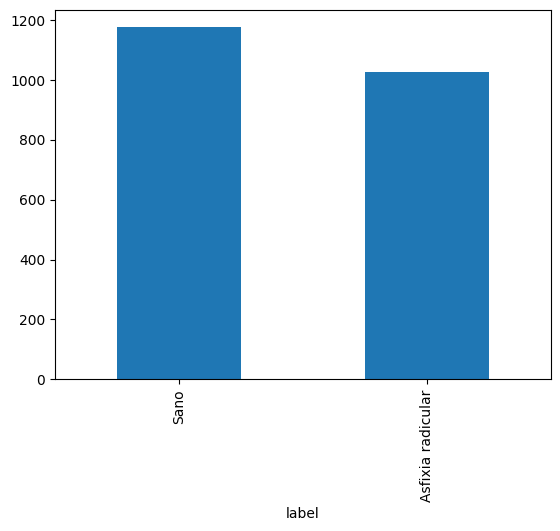

In [31]:
# Analizar el porcentaje de datos que tienen asfixia radicular y los que estan sanos
df['label'].value_counts(normalize=True) * 100

# Graficar la cantidad de datos que tienen asfixia radicular y los que estan sanos
df['label'].value_counts().plot(kind='bar')
plt.show()


In [32]:
# Guardar dataset en un csv que diga 'Dataset_AsfixiaRadicular.csv'
df.to_csv('Dataset_AsfixiaRadicular.csv', index=False)

In [33]:
# quiero saber los rangos de valores de N, P y K que tienen los datos
df.describe()


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,24.072294,25.410823,22.928139,25.616244,71.481779,6.469480,103.463655
std,17.579683,15.707563,24.118062,5.063749,22.263812,0.773938,54.958389
min,0.000000,2.380952,2.380952,8.825675,14.258040,3.504752,20.211267
25%,10.000000,13.333333,9.523810,22.769375,60.261953,5.971693,64.551686
50%,17.619048,24.285714,15.238095,25.598693,80.473146,6.425045,94.867624
75%,40.119048,32.380952,23.333333,28.561654,89.948771,6.923643,124.267508
max,66.666667,69.047619,97.619048,43.675493,99.981876,9.935091,298.560117
